# BhuvanFitter — gene-expression distribution fitting

Per-gene tools, imported from `bhuvanfitter.py` (the single source of truth).
`BhuvanFitter` supports two fit models via the same `fit()` / `hist()` interface:

- **`fit("fourparam")`** — fits a 4-parameter Gaussian to the 40-bin histogram by
  ordinary least squares and returns
  `gene, y0, A, x0, w, sumsquarevalue, ti_fourparam_sigma_dist, truncationindex,
  min, max, right, maxheight, rightheight, n_obs, fit_success`. The
  truncation-index metrics use `x_max` (default = observed max):
  **`ti_fourparam_sigma_dist`** = `(x_max − x0) / (w/√2)` and **`truncationindex`**
  = `rightheight / maxheight` (NaN for a degenerate peak ≤ data min).
- **`fit("kde")`** — runs a bin-independent Gaussian KDE and detects its modes
  (reusing `gene_peaks`), returning `gene, n_peaks, peaks, bw_method, n_obs,
  fit_success`, where `peaks` is `{value: {"height", "prominence"}}`.

`hist(lines=["fourparam", "kde"])` overlays either/both fitted curves on the
histogram (the KDE scaled to bin counts, with markers at detected peaks), but
only after the corresponding `fit` has been run.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The fitting library is the single source of truth (bhuvanfitter.py) — the
# model, the BhuvanFitter class, and gene_peaks all live there.
from bhuvanfitter import BhuvanFitter, gene_peaks

## 2. The 4-Parameter Gaussian Model

$$y = y_0 + A \cdot \exp\!\left(-\left(\frac{x - x_0}{w}\right)^2\right)$$

| Parameter | Meaning |
|---|---|
| `y0` | Baseline offset |
| `A`  | Amplitude (peak height above baseline) |
| `x0` | Centre of the peak |
| `w`  | Width parameter (`w = σ√2`) |

Lives in `bhuvanfitter.py` as the module-level `_fourparam_gaussian` (module
level because `scipy.optimize.curve_fit` needs a plain picklable callable). It is
imported above with `BhuvanFitter` — do **not** redefine it here, or the inline
copy will shadow the import and break (it would need its own `curve_fit` import).

## 3. The `BhuvanFitter` Class

The main interface, imported from `bhuvanfitter.py` (cell 1). It cleans the data,
caches a 40-bin histogram, and dispatches fits through `fit(model)`:

- `fit("fourparam")` — 4-parameter Gaussian by ordinary least squares + the
  truncation-index metrics.
- `fit("kde")` — Gaussian KDE mode detection (reuses `gene_peaks`).

`hist(lines=[...])` overlays any fits that have been run. All analysis logic lives
in the module so the notebook, `generate_fourparam_stats.py`, and
`generate_peaks.py` share one implementation — keep it imported, not redefined.

## 4. Example

A quick synthetic check: fit a Gaussian sample and overlay the fitted curve.

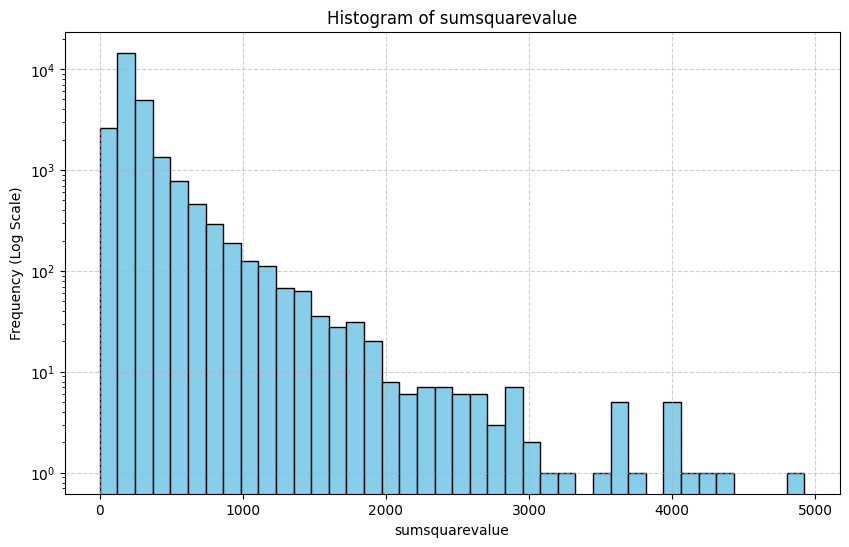

In [4]:
fourparam_df = pd.read_csv("fourparam_table.csv")
master = pd.read_csv('Supplementary Data 1_csv.csv').set_index('strain')
master = master.T


squaredata = fourparam_df['sumsquarevalue'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(squaredata, bins=40, color='skyblue', edgecolor='black')
plt.title('Histogram of sumsquarevalue')
plt.xlabel('sumsquarevalue')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
fitter = BhuvanFitter(master['w1_Y110A7A.10.1'], "w1_Y110A7A.10.1")
fitter.fit("fourparam")     # runs the 4-param Gaussian
fitter.fit("kde")           # runs the KDE fit
fitter.hist(lines=["fourparam", "kde"])   # overlay both

NameError: name 'curve_fit' is not defined